## Test data augmentation transformations

input to albumentations 0.0 1.0 (256, 256, 3)


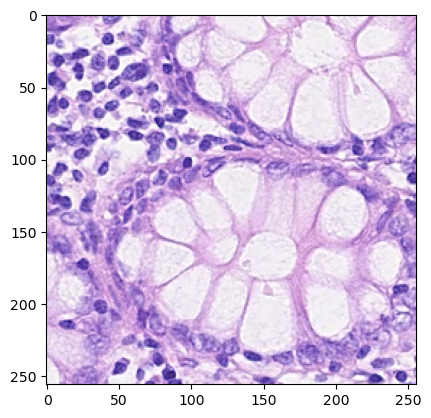

In [409]:
import albumentations as A
import cv2
import numpy as np
import numpy as np
from tifffile import imread
import matplotlib.pyplot as plt

image = np.array(imread('../data/OME-TIFFs/consep_11-0002.ome.tif'))[0:3, :, :].transpose(1, 2, 0).astype(np.int64)  

plt.imshow(image)

image = image.astype(np.float32)/255
print("input to albumentations", image.min(), image.max(), image.shape)

out image 0.0 1.0 (256, 256, 3)


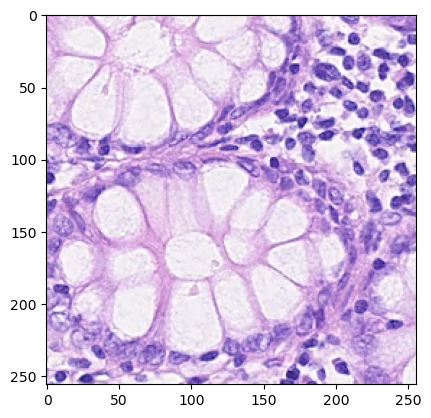

In [281]:
transform = A.HorizontalFlip(p=1.0)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)
print("out image", transformed_image.min(), transformed_image.max(), transformed_image.shape)

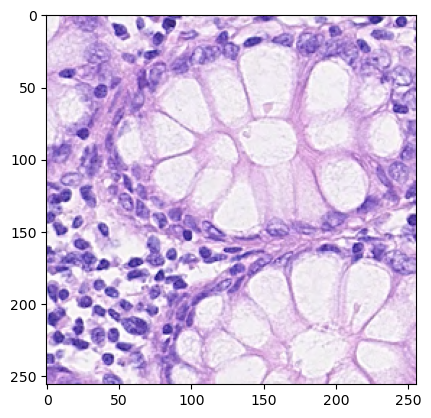

In [282]:
transform = A.VerticalFlip(p=1.0)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)

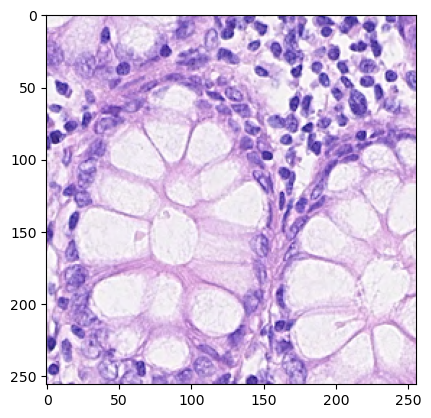

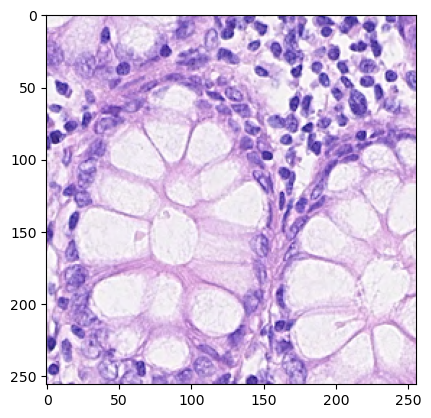

In [283]:
transform = A.RandomRotate90(p=1.0)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)
plt.show()

transform = A.RandomRotate90(p=1.0)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)

output image 0.13971223 0.99922884 (256, 256, 3)


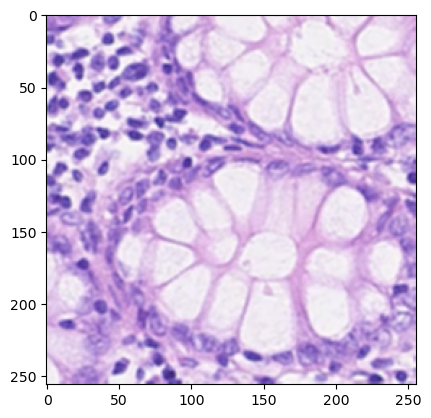

In [291]:
transform = A.GaussianBlur(blur_limit=(1, 3), p=1.0)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)
print("output image", transformed_image.min(), transformed_image.max(), transformed_image.shape)

output image 0.0 1.0 (256, 256, 3)


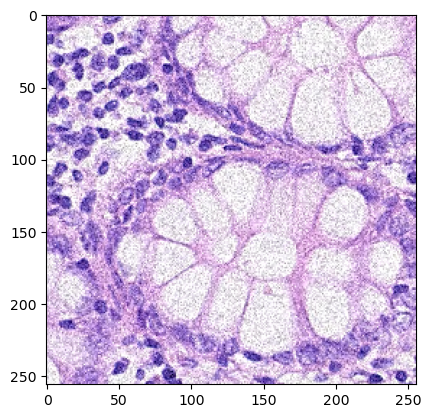

In [308]:
transform = A.GaussNoise(std_range=(0.05, 0.1), p=1.0)
transformed_data = transform(image=image)
transformed_image = (transformed_data['image'])

plt.imshow(transformed_image)
print("output image", transformed_image.min(), transformed_image.max(), transformed_image.shape)

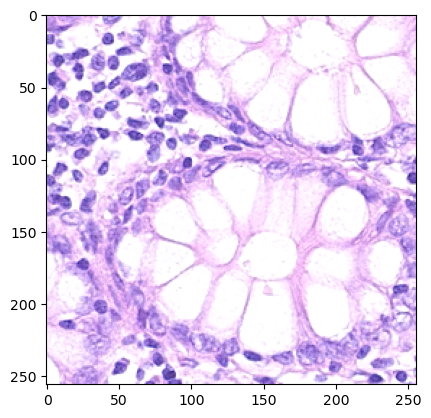

In [398]:
transform = A.RandomBrightnessContrast(brightness_limit=(-0.1,0.1), contrast_limit=(-0.1, 0.1), p=1.0)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)

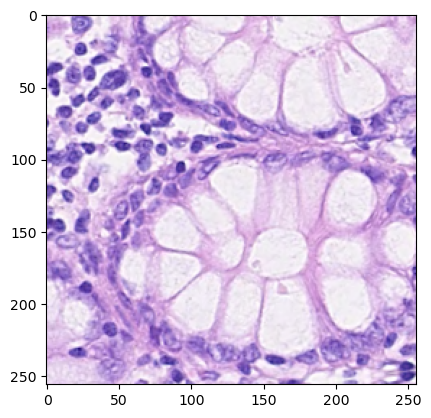

In [421]:
transform = A.Affine(scale=(0.8, 1.2), rotate=(-15, 15), p=1.0, border_mode=cv2.BORDER_REFLECT_101)
transformed_data = transform(image=image)
transformed_image = transformed_data['image']

plt.imshow(transformed_image)

In [1]:
import os
import pandas as pd

folder_path = "../data/OME-TIFFs"  
output_csv = "../data/patches/patch_info.csv"

names = []

for fname in os.listdir(folder_path):
    if fname.endswith(".ome.tif"):
        base_name = fname.replace(".ome.tif", "")
        names.append(base_name)

df = pd.DataFrame(names, columns=["name"])

df.to_csv(output_csv, index=False)

In [2]:
print(len(names))

4981
